In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
from utilv3 import *
import cv2
import pandas as pd
from pathlib import Path

#for display purposes
def normalize_raster(raster):
    """Normalize raster values to 0–255 for display, returning uint8."""
    raster_min = np.nanmin(raster)
    raster_max = np.nanmax(raster)
    
    if raster_max == raster_min:
        return np.zeros_like(raster, dtype=np.uint8)  # avoid divide by zero
    
    normalized = (raster - raster_min) / (raster_max - raster_min)
    return (normalized * 255).astype(np.uint8)

def update_row(df, key_col, key_val, updates):
    """
    Update a row in a DataFrame by matching key_col == key_val.

    Parameters:
    - df: pandas DataFrame
    - key_col: column name to match (e.g., 'id')
    - key_val: value to find in key_col
    - updates: dict of column:value pairs to update

    Returns:
    - Updated DataFrame (in place)
    """

    # Add missing columns (ignore index column)
    for col in updates.keys():
        if col not in df.columns and col != df.index.name:
            df[col] = None  # create new column with None values

    mask = df[key_col] == key_val
    if mask.any():
        # Update existing row
        for col, val in updates.items():
            if col in df.columns:
                df.loc[mask, col] = val
    else:
        # Build a new row with all columns accounted for (ignore index column)
        new_row = {col: None for col in df.columns}
        new_row[key_col] = key_val
        for col, val in updates.items():
            if col in df.columns:
                new_row[col] = val
        df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)

    return df

Instructions:
Preliminary: Please find the list of FMRs with available images in this file: "...\OneDrive - Philippine Space Agency\SDMAD_SHARED\PROJECTS\SAKA\FMR\.BAFE - FMR (DPWH)\FMR-vectors\fmr_with_images.csv"

0. Kindly change the PATH of the MASTER FILE (replace the "user-.....")
1. Input the image path in "raster_path"
2. Input the centerline path in "vector_path"2.1 Centerline per FMR should be exported from the Master_FMR
2.2 Save exported FMR in "\OneDrive - Philippine Space Agency\SDMAD_SHARED\PROJECTS\SAKA\FMR\.BAFE - FMR (DPWH)\FMR-vectors"
2.3 Exported FMR format: "FMR-##.geojson" 
3. Input the output path in "output_folder" : "\OneDrive - Philippine Space Agency\SDMAD_SHARED\PROJECTS\SAKA\FMR\.BAFE - FMR (DPWH)\Outputs"
4. Run Cell 2, check if the image has good quality/suitable for automatic processing.
4.1 If FMR has multiple images, check each image and select the best image available. Proceed to next step.
4.2 If there's no good quality image, kindly note in the csv (mentioned at the top), add remarks column if it does not exist. Run next cell (Cell 3) Proceed to next FMR.
5. Run the next cell (Cell 4).

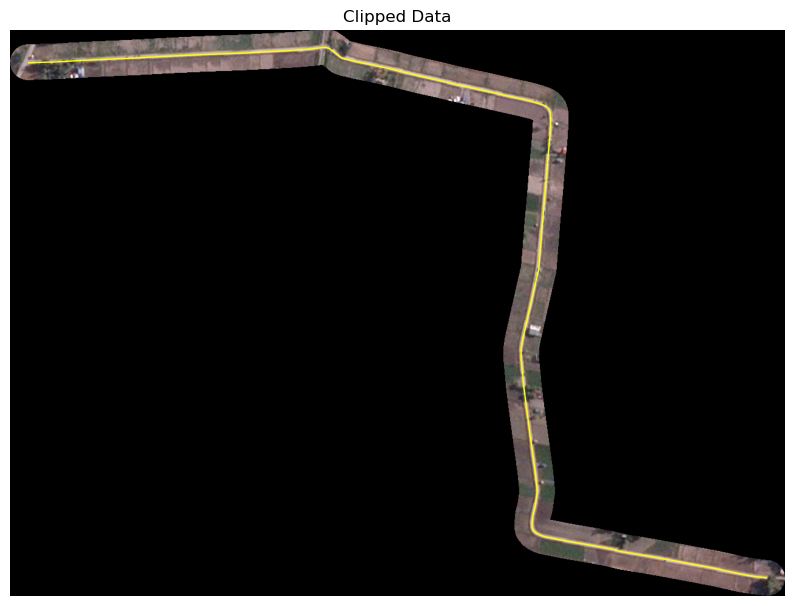

In [6]:
## FOR one-by-one processing of FMR in compliance to DA-BAFE's request
## Steps 1-4
results = {}

master_file_path = r"C:\Users\user-307E4B3400\OneDrive - Philippine Space Agency\SDMAD_SHARED\PROJECTS\SAKA\FMR\.BAFE - FMR (DPWH)\FMR-vectors\fmr_with_images.csv"
master_file = pd.read_csv(master_file_path)

raster_path = r"C:\Users\user-307E4B3400\OneDrive - Philippine Space Agency\SDMAD_SHARED\PROJECTS\SAKA\FMR\GUI\Raster images\BSG-115-20240601-230820-244317407-Tiff.tif"
vector_path = r"C:\Users\user-307E4B3400\OneDrive - Philippine Space Agency\SDMAD_SHARED\PROJECTS\SAKA\FMR\.BAFE - FMR (DPWH)\FMR-vectors\FMR-317.geojson"

vector_basename = Path(vector_path).stem    ## gets only the filename; for file/folder naming purposes
vector_gdf = gpd.read_file(vector_path)

output_folder = rf"C:\Users\user-307E4B3400\OneDrive - Philippine Space Agency\SDMAD_SHARED\PROJECTS\SAKA\FMR\.BAFE - FMR (DPWH)\Outputs\{vector_basename}"

image_output_path = os.path.join(output_folder, "Output Images")
os.makedirs(image_output_path, exist_ok=True)

preprocessor = Preprocessing()
preprocessor.reproject(raster_path)

clipped_data, clipped_transform = preprocessor.clipraster(vector_data=vector_gdf, buffer_dist=25) #bbox=False
clipped_data_box, clipped_transform_box = preprocessor.clipraster(vector_data=vector_gdf, bbox=True) #for exporting purposes

#for display only
display_image = normalize_raster(clipped_data)

fig, ax = plt.subplots(figsize=(10, 10))
show(display_image, ax=ax, transform=clipped_transform)
vector_gdf.plot(ax=ax, color='yellow', edgecolor=None, linewidth=1)
ax.set_title("Clipped Data")
ax.axis("off")
plt.savefig(f"{image_output_path}-{vector_basename}-clippedData.png", bbox_inches="tight")
plt.show()

##If image is good-to-go proceed to next step

In [ ]:
## ---------- IF image is bad, RUN THIS ------------- ##
results['Remarks'] = ""         #Type here remarks on the image

updated_csv = update_row(master_file, "FMR", vector_basename, results)

updated_csv.to_csv(master_file_path)

results

{'Remarks': 'Obstructed by clouds. Bad image.'}

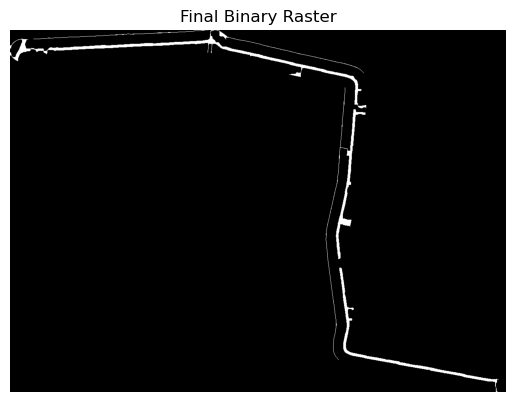

c:\Users\user-307E4B3400\anaconda3\envs\bafe2\lib\site-packages\shapely\constructive.py:181: RuntimeWarning: divide by zero encountered in buffer
  return lib.buffer(


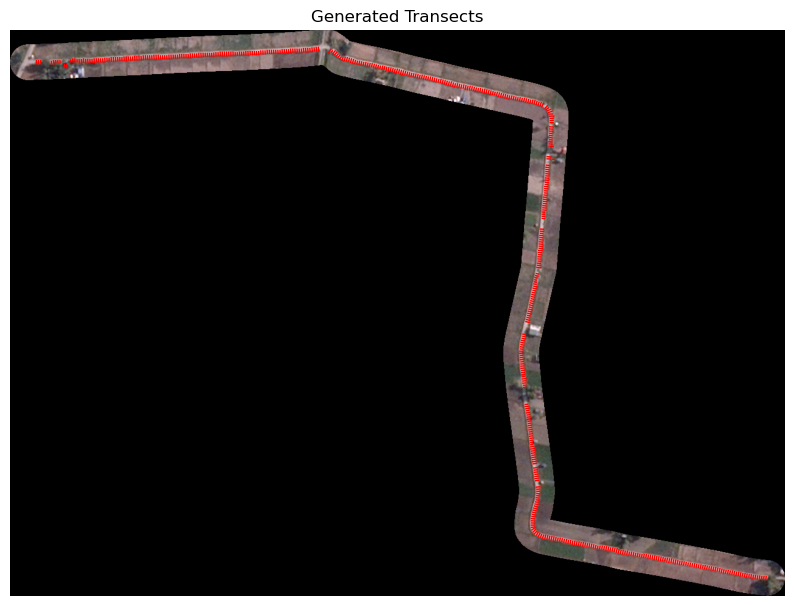

In [7]:
#Processing of the clipped image; filters, morphological operations, viewing results

filter = Filters()
warm_raster = filter.enhance_image_warmth(clipped_data)
stretch_raster = filter.enhance_linear_stretch(clipped_data)

morph = Morph()
morph_warm = morph.process(warm_raster, a=4, b=3, ite1=2, ite2=3)
morph_stretch = morph.process(stretch_raster, a=4, b=3, ite1=2, ite2=3)

merged_or = np.logical_or(morph_warm, morph_stretch)
initial_binary_raster = merged_or

final_binary_transform = clipped_transform

final_binary_raster = morph.remove_small_islands(initial_binary_raster, min_size=500)

#---------------------- Export 1
final_binary_raster = np.squeeze(final_binary_raster)
final_binary_raster = cv2.morphologyEx(final_binary_raster.astype(np.uint8), cv2.MORPH_CLOSE, np.ones((3,3), np.uint8), iterations=3) 

plt.imshow(final_binary_raster, cmap="gray")
plt.axis("off")
plt.title("Final Binary Raster")
plt.savefig(f"{image_output_path}-{vector_basename}-Binary.png", bbox_inches="tight")
plt.show()

int, tol, res = 3, 0.15, 0.3

measure = MeasureWidth(final_binary_raster, final_binary_transform, vector_gdf)

#---------------------- Export 2
transects = measure.process(int=int, tol=tol, res=res)
road_mean = transects['width'].mean()

fig, ax = plt.subplots(figsize=(10, 10))
show(display_image, ax=ax, transform=final_binary_transform)
transects.plot(ax=ax, color='red', edgecolor=None, linewidth=1)
ax.set_title("Generated Transects")
ax.axis("off")
plt.savefig(f"{image_output_path}-{vector_basename}-Transects.png", bbox_inches="tight")
plt.show()

For the centerline extraction, there are three methods of connecting the points now available:

(1) Minimum Spanning Tree ("mst") - connects according to the "fastest" way a line can travel across points

(2) Nearest Neighbor ("nearest") - connects according to the nearest point

(3) Sequential ("sequential") - connects the points according to the sequence of points (leftmost to rightmost/topmost to bottom)

The default method will be "mst". IF the resulting line of this does not align with the produced Binary Raster or Transects, kindly use the next method, "nearest", then followed by "sequential". ONLY CHANGE METHODS IF RESULTS ARE NOT ACCEPTABLE.

If even by using three methods, the results are not desirable, kindly note in the "Remarks" line (in the next cell)

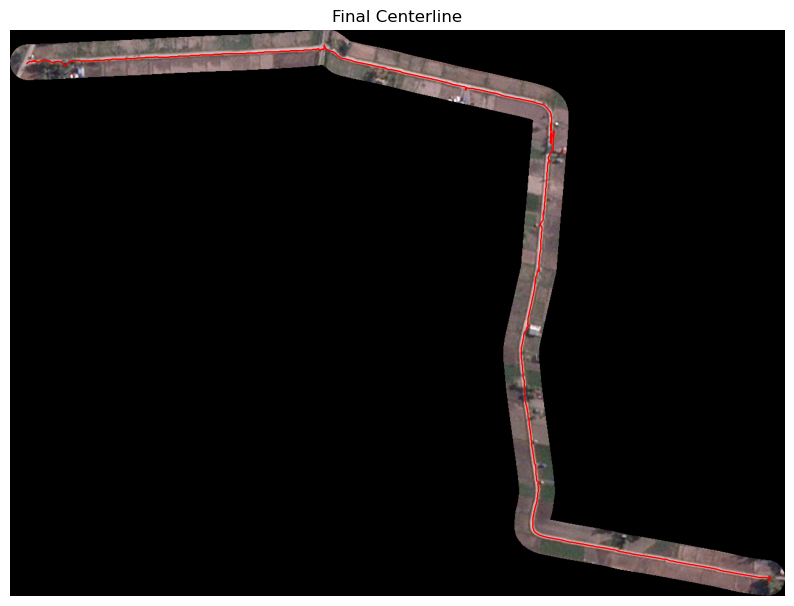

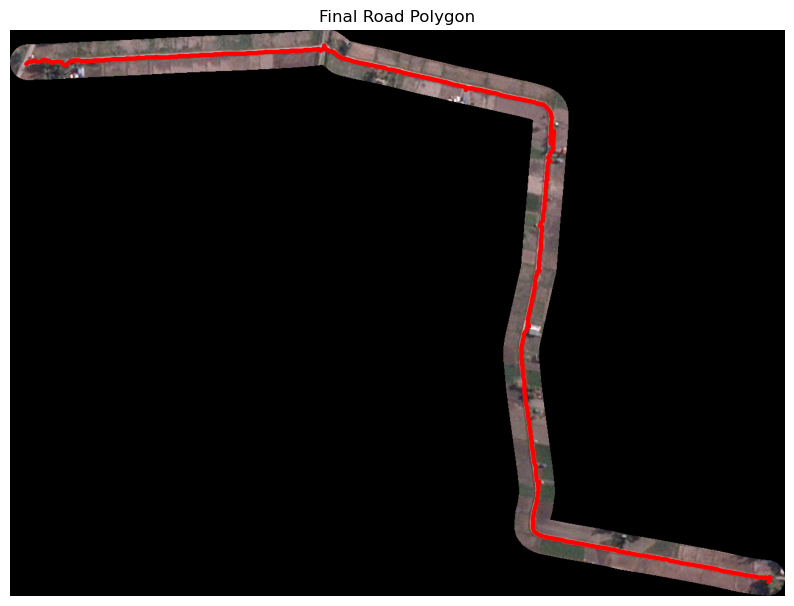

In [8]:
##CENTERLINE EXTRACTION FROM SKELETONIZED FINAL_BINARY_RASTER
# Clip final binary raster for centerline extraction
final_binary_raster, final_binary_transform = preprocessor.clipraster(
                    raster_data = final_binary_raster.astype(np.uint8),
                    vector_data = vector_gdf,
                    transform = clipped_transform,
                    buffer_dist = 7.5)
final_binary_raster = np.squeeze(final_binary_raster)

# Generate Centerline
#---------------------- Export 3
extractor = CenterlineExtractor(
    raster_array=final_binary_raster,
    transform=final_binary_transform,
    crs='EPSG:32651'
)

# -------------------- centerline method --------------------- #
connection_method = 'mst' # options are "nearest" , "mst", "sequential"

centerline = extractor.extract_centerlines()
connected_centerline = extractor.connect_lines(centerline, tolerance=30.0, method='mst') 
final_line = extractor.smooth_lines(connected_centerline, method='gaussian') #smoothed using gaussian

fig, ax = plt.subplots(figsize=(10, 10))
show(display_image, ax=ax, transform=clipped_transform)
final_line.plot(ax=ax, color='red', edgecolor=None, linewidth=1)
ax.set_title("Final Centerline")
ax.axis("off")
plt.savefig(f"{image_output_path}-{vector_basename}-Centerline ({connection_method}).png", bbox_inches="tight")
plt.show()

# Generate Polygon
#---------------------- Export 4
road_polygon = create_polygon(final_line, road_width=road_mean)

fig, ax = plt.subplots(figsize=(10, 10))
show(display_image, ax=ax, transform=clipped_transform)
road_polygon.plot(ax=ax, color='red', edgecolor=None, linewidth=1)
ax.set_title("Final Road Polygon")
ax.axis("off")
plt.savefig(f"{image_output_path}-{vector_basename}-Polygon.png", bbox_inches="tight")
plt.show()

In [11]:
#SUMMARY CELL
actual_length = final_line.length.values[0]
theo_length = vector_gdf.to_crs("EPSG:32651").length.sum()
progress = (actual_length / theo_length) * 100
if theo_length and theo_length > 0:
    progress = float((actual_length / theo_length) * 100.0)
    if progress > 90 and progress < 110:
        status = "Completed"
    elif progress == 0:
        status = "Not Started"
    else:
        status = "Erroneous processing"


# Summary of results
results['FMR'] = vector_basename
results['Planned FMR Length'] = theo_length
results['Current FMR Length'] = actual_length
results['FMR Progress'] = progress
results['FMR Status'] = status          #current threshold of this is 10
results['Mean FMR Width'] = measure.transects['width'].mean()

results['Remarks'] = "new centerline extraction, GOOD IMAGE, BINARY, AND TRANSECTS" #input your remarks here

updated_csv = update_row(master_file, "FMR", vector_basename, results)

updated_csv.to_csv(master_file_path)

results


{'FMR': 'FMR-317',
 'Planned FMR Length': 1678.5553624165163,
 'Current FMR Length': 1834.737151037637,
 'FMR Progress': 109.30453603843455,
 'FMR Status': 'Completed',
 'Mean FMR Width': 6.058710541685071,
 'Remarks': 'new centerline extraction, GOOD IMAGE, BINARY, AND TRANSECTS'}

In [12]:
## Exports
# Export clipped RGB image
clipped_image_path = os.path.join(output_folder, f"{vector_basename}_clipped_image.tif")
export(clipped_data_box, clipped_image_path, 'raster', 'EPSG:32651', raster_transform=clipped_transform)

# Export intermediate binary raster
binary_raster_path = os.path.join(output_folder, f"{vector_basename}_binary_raster.tif")
export(final_binary_raster, binary_raster_path, 'raster', 'EPSG:32651', raster_transform=final_binary_transform)

# Export final line (Actual Line)
final_line_path = os.path.join(output_folder, f"{vector_basename}_centerline ({connection_method}).shp")
export(final_line, final_line_path, 'vector', 'EPSG:32651')

#Export final polygon (generated from mean width and final centerline)
road_polygon_path = os.path.join(output_folder, f"{vector_basename}_road_polygon ({connection_method}).shp")
export(road_polygon, road_polygon_path, 'vector', 'EPSG:32651')

Raster exported successfully to C:\Users\user-307E4B3400\OneDrive - Philippine Space Agency\SDMAD_SHARED\PROJECTS\SAKA\FMR\.BAFE - FMR (DPWH)\Outputs\FMR-317\FMR-317_clipped_image.tif
Raster exported successfully to C:\Users\user-307E4B3400\OneDrive - Philippine Space Agency\SDMAD_SHARED\PROJECTS\SAKA\FMR\.BAFE - FMR (DPWH)\Outputs\FMR-317\FMR-317_binary_raster.tif
Vector exported successfully to C:\Users\user-307E4B3400\OneDrive - Philippine Space Agency\SDMAD_SHARED\PROJECTS\SAKA\FMR\.BAFE - FMR (DPWH)\Outputs\FMR-317\FMR-317_centerline (mst).shp
Vector exported successfully to C:\Users\user-307E4B3400\OneDrive - Philippine Space Agency\SDMAD_SHARED\PROJECTS\SAKA\FMR\.BAFE - FMR (DPWH)\Outputs\FMR-317\FMR-317_road_polygon (mst).shp


WORKFLOW ENDS HERE ------------- CELLS BELOW THIS ARE SCRATCH ------------- DO NOT RUN

In [ ]:
# fmr_db_file = r"C:\Users\user-307E4B3400\OneDrive - Philippine Space Agency\SDMAD_SHARED\PROJECTS\SAKA\FMR\.BAFE - FMR (DPWH)\FMR-vectors\fmr_with_images.csv"

# df = pd.read_csv(fmr_db_file)
# df = df[df["Image Path"].notna() & df["Image Path"].astype(str).str.strip().ne("")]

# # Extract numeric index from "FMR" column like "FMR_0"
# fmr_ids = df["FMR"].str.extract(r"FMR-(\d+)", expand=False).dropna().astype(int).unique().tolist()
# # print(fmr_ids)

# gdf = gpd.read_file(r"C:\Users\user-307E4B3400\OneDrive - Philippine Space Agency\SDMAD_SHARED\PROJECTS\SAKA\FMR\GUI\Master FMR\NE_master_fmr.shp")

# for fmr_id in fmr_ids:
#     fmr_geometry = gdf.loc[fmr_id].geometry
#     fmr_gdf = gpd.GeoDataFrame({"geometry": [fmr_geometry]}, crs="EPSG:32651")

#     output_folder = rf"C:\Users\user-307E4B3400\OneDrive - Philippine Space Agency\SDMAD_SHARED\PROJECTS\SAKA\FMR\.BAFE - FMR (DPWH)\FMR-vectors"

#     fmr_output_path = os.path.join(output_folder, f"FMR-{fmr_id}.geojson")
#     export(fmr_gdf, fmr_output_path, 'vector', 'EPSG:32651')

In [ ]:
# image_output_path = os.path.join(output_folder, "Output Images", f"{vector_basename}")
# print(image_output_path)

# print(f"{image_output_path}-clippedData.png")

C:\Users\user-307E4B3400\\OneDrive - Philippine Space Agency\SDMAD_SHARED\PROJECTS\SAKA\FMR\.BAFE - FMR (DPWH)\Outputs\FMR-317\Output Images\FMR-317
C:\Users\user-307E4B3400\\OneDrive - Philippine Space Agency\SDMAD_SHARED\PROJECTS\SAKA\FMR\.BAFE - FMR (DPWH)\Outputs\FMR-317\Output Images\FMR-317-clippedData.png


In [5]:
## New measure_line

import numpy as np
import skimage.morphology
import rasterio.transform
import shapely.geometry
import geopandas as gpd
from sklearn.neighbors import NearestNeighbors
from scipy.interpolate import splprep, splev
from scipy.spatial.distance import cdist
import networkx as nx

def measure_line_new(raster_data, transform, spacing=3, 
                return_points=False, crs="EPSG:32651", road_width=None, 
                return_polygon=False, smoothing_factor=0.1, min_distance=5.0):
    """
    Create a continuous road centerline from left to right from binary raster.
    Optionally create road polygon with specified width.
    
    Parameters:
    - raster_data: 2D numpy array (1=road, 0=non-road)
    - transform: affine transform from original raster
    - spacing: sample every N pixels (default=3)
    - return_points: if True, returns both points and line
    - crs: coordinate reference system
    - road_width: width of road in map units (e.g., meters). If None, only returns centerline
    - return_polygon: if True and road_width is specified, returns polygon instead of line
    - smoothing_factor: spline smoothing parameter (0=no smoothing, higher=more smoothing)
    - min_distance: minimum distance between consecutive points in map units
    
    Returns:
    - GeoDataFrame with centerline or road polygon (and optionally points)
    """
    
    # Get skeleton
    skeleton = skimage.morphology.skeletonize(raster_data)
    y_coords, x_coords = np.where(skeleton)
    
    if len(x_coords) == 0:
        # Return empty geometry if no skeleton found
        empty_line = shapely.geometry.LineString()
        return gpd.GeoDataFrame(geometry=[empty_line], crs=crs)
    
    # Sample points with spacing
    x_coords = x_coords[::spacing]
    y_coords = y_coords[::spacing]
    
    # Convert to real-world coordinates
    xx, yy = rasterio.transform.xy(transform, y_coords, x_coords)
    coords = np.array(list(zip(xx, yy)))
    
    # Remove duplicate points
    coords = _remove_duplicates(coords, min_distance)
    
    if len(coords) < 2:
        # Need at least 2 points for a line
        empty_line = shapely.geometry.LineString()
        return gpd.GeoDataFrame(geometry=[empty_line], crs=crs)
    
    # Create ordered path using graph-based approach
    ordered_coords = _create_ordered_path(coords)
    
    # Smooth the line using spline interpolation
    if len(ordered_coords) > 3 and smoothing_factor > 0:
        smoothed_coords = _smooth_line(ordered_coords, smoothing_factor)
    else:
        smoothed_coords = ordered_coords
    
    # Create LineString
    line = shapely.geometry.LineString(smoothed_coords)
    
    # Create points GeoDataFrame for return
    points = [shapely.geometry.Point(x, y) for x, y in smoothed_coords]
    points_gdf = gpd.GeoDataFrame(geometry=points, crs=crs)
    
    # Handle road width and polygon creation
    if road_width is not None:
        # Buffer the line to create a polygon with specified width
        road_polygon = line.buffer(road_width / 2, cap_style=1, join_style=1)
        
        if return_polygon:
            # Return polygon instead of line
            result_gdf = gpd.GeoDataFrame(geometry=[road_polygon], crs=crs)
        else:
            # Return line as default
            result_gdf = gpd.GeoDataFrame(geometry=[line], crs=crs)
            polygon_gdf = gpd.GeoDataFrame(geometry=[road_polygon], crs=crs)
    else:
        # Original behavior - return line only
        result_gdf = gpd.GeoDataFrame(geometry=[line], crs=crs)
    
    # Return based on parameters
    if return_points and road_width is not None and not return_polygon:
        return (result_gdf, points_gdf, polygon_gdf)
    elif return_points:
        return (result_gdf, points_gdf)
    elif road_width is not None and return_polygon:
        return gpd.GeoDataFrame(geometry=[road_polygon], crs=crs)
    else:
        return result_gdf


def _remove_duplicates(coords, min_distance):
    """Remove points that are too close together."""
    if len(coords) <= 1:
        return coords
    
    filtered_coords = [coords[0]]
    for coord in coords[1:]:
        if np.min(cdist([coord], filtered_coords)) >= min_distance:
            filtered_coords.append(coord)
    
    return np.array(filtered_coords)


def _create_ordered_path(coords):
    """Create an ordered path through points using graph-based approach."""
    n_points = len(coords)
    
    if n_points < 2:
        return coords
    
    # Create a graph connecting nearby points
    G = nx.Graph()
    
    # Add all points as nodes
    for i in range(n_points):
        G.add_node(i, pos=coords[i])
    
    # Connect each point to its k nearest neighbors (typically 2-4 for road-like structures)
    k = min(4, n_points - 1)
    nbrs = NearestNeighbors(n_neighbors=k + 1).fit(coords)  # +1 because it includes the point itself
    distances, indices = nbrs.kneighbors(coords)
    
    for i in range(n_points):
        for j in range(1, len(indices[i])):  # Skip the first one (the point itself)
            neighbor_idx = indices[i][j]
            distance = distances[i][j]
            
            # Only connect if the distance is reasonable (not too far)
            # This prevents connecting distant points that shouldn't be connected
            median_distance = np.median(distances[:, 1])  # Median nearest neighbor distance
            if distance <= 3 * median_distance:
                G.add_edge(i, neighbor_idx, weight=distance)
    
    # Find endpoints (nodes with degree 1) or use extremes
    degrees = dict(G.degree())
    endpoints = [node for node, degree in degrees.items() if degree <= 2]
    
    if len(endpoints) < 2:
        # If no clear endpoints, use the two most distant points
        distances_matrix = cdist(coords, coords)
        start_idx, end_idx = np.unravel_index(distances_matrix.argmax(), distances_matrix.shape)
        endpoints = [start_idx, end_idx]
    
    # Find the longest path between endpoints (or create one if graph is disconnected)
    try:
        if len(endpoints) >= 2:
            # Try to find path between different endpoints
            best_path = None
            best_length = 0
            
            for i in range(len(endpoints)):
                for j in range(i + 1, len(endpoints)):
                    try:
                        path = nx.shortest_path(G, endpoints[i], endpoints[j], weight='weight')
                        path_length = len(path)
                        if path_length > best_length:
                            best_path = path
                            best_length = path_length
                    except nx.NetworkXNoPath:
                        continue
            
            if best_path is not None:
                ordered_coords = coords[best_path]
            else:
                # Fallback: create path using nearest neighbor
                ordered_coords = _fallback_path_creation(coords)
        else:
            ordered_coords = _fallback_path_creation(coords)
            
    except Exception:
        # If graph approach fails, use fallback
        ordered_coords = _fallback_path_creation(coords)
    
    return ordered_coords


def _fallback_path_creation(coords):
    """Fallback method for path creation using improved nearest neighbor approach."""
    n_points = len(coords)
    
    # Find the leftmost point as starting point
    start_idx = np.argmin(coords[:, 0])
    
    path = [start_idx]
    remaining = set(range(n_points)) - {start_idx}
    current_pos = coords[start_idx]
    
    while remaining:
        remaining_coords = coords[list(remaining)]
        distances = cdist([current_pos], remaining_coords)[0]
        
        # Choose next point based on distance and direction
        # Prefer points that continue in a similar direction
        if len(path) > 1:
            prev_pos = coords[path[-2]]
            current_direction = current_pos - prev_pos
            current_direction = current_direction / (np.linalg.norm(current_direction) + 1e-8)
            
            scores = []
            for i, remaining_idx in enumerate(remaining):
                distance = distances[i]
                next_pos = coords[remaining_idx]
                next_direction = next_pos - current_pos
                next_direction = next_direction / (np.linalg.norm(next_direction) + 1e-8)
                
                # Directional consistency score (higher is better)
                direction_score = np.dot(current_direction, next_direction)
                
                # Combined score (lower is better)
                combined_score = distance * (2.0 - direction_score)
                scores.append(combined_score)
            
            next_idx_in_remaining = np.argmin(scores)
        else:
            next_idx_in_remaining = np.argmin(distances)
        
        next_idx = list(remaining)[next_idx_in_remaining]
        path.append(next_idx)
        remaining.remove(next_idx)
        current_pos = coords[next_idx]
    
    return coords[path]


def _smooth_line(coords, smoothing_factor):
    """Smooth the line using spline interpolation."""
    if len(coords) < 4:
        return coords
    
    try:
        # Prepare data for spline fitting
        x = coords[:, 0]
        y = coords[:, 1]
        
        # Create parameter values for the spline
        t = np.linspace(0, 1, len(coords))
        
        # Fit spline
        tck, u = splprep([x, y], s=smoothing_factor * len(coords), k=min(3, len(coords) - 1))
        
        # Evaluate spline at more points for smoother result
        u_new = np.linspace(0, 1, max(len(coords), 50))
        smooth_x, smooth_y = splev(u_new, tck)
        
        return np.column_stack([smooth_x, smooth_y])
        
    except Exception:
        # If spline fitting fails, return original coordinates
        return coords